# 03 - Mining and Clustering (Bank Marketing)

Mục tiêu:
- Thực hiện phân cụm khách hàng để khám phá nhóm khách hàng theo behaviors.
- Chọn K tốt nhất dựa trên Elbow + Silhouette.
- Profiling cụm và tạo insight.

Numeric cols: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


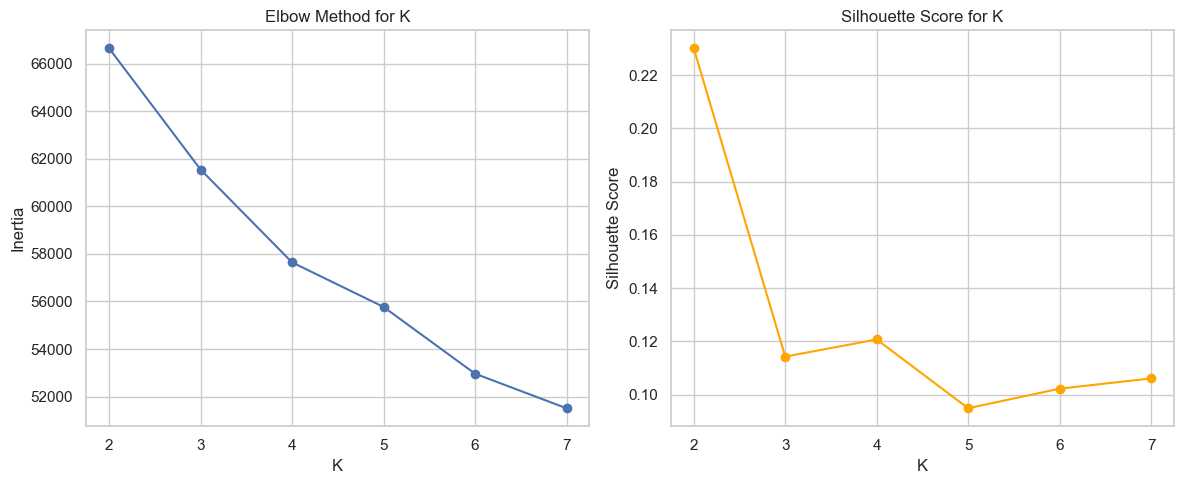

Best K by silhouette: 2


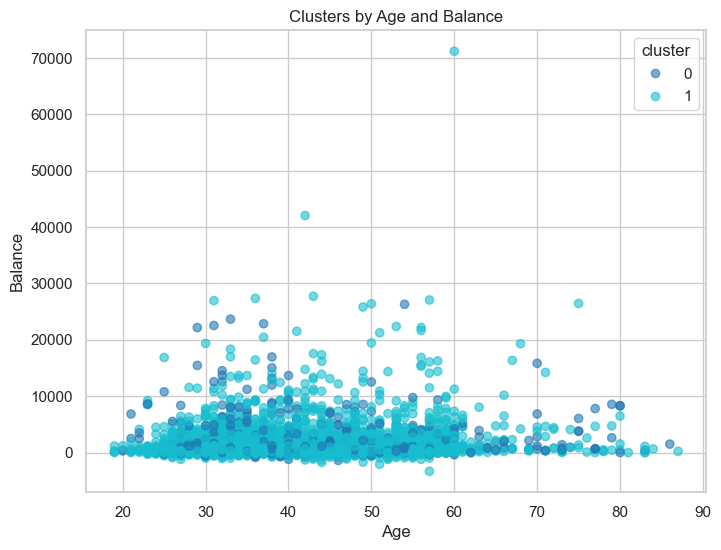

               age                    job                marital               \
              mean median count      mean median count      mean median count   
cluster                                                                         
0        41.386852   38.0   791  4.359039    4.0   791  1.188369    1.0   791   
1        41.124129   39.0  3730  4.422252    4.0  3730  1.139142    1.0  3730   

        education  ... previous  poutcome                      y               \
             mean  ...    count      mean median count      mean median count   
cluster            ...                                                          
0        1.292035  ...      791  0.515803    0.0   791  0.218710    0.0   791   
1        1.218499  ...     3730  2.992493    3.0  3730  0.093298    0.0  3730   

                                
             mean median count  
cluster                         
0        0.218710    0.0   791  
1        0.093298    0.0  3730  

[2 rows x 54 columns]


C:\Users\Duong\AppData\Local\Temp\ipykernel_3204\11713911.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=col, data=df, palette='Set2')


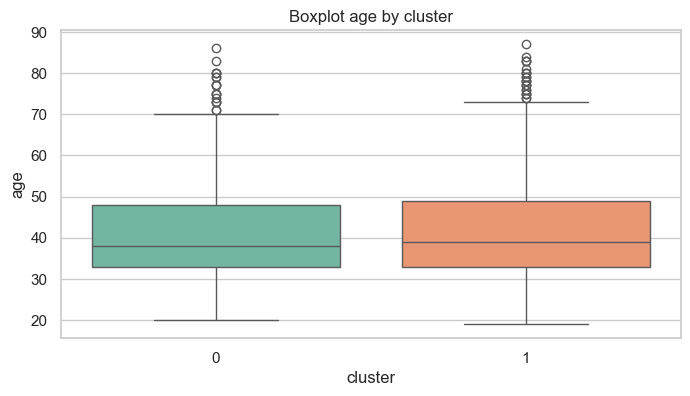

C:\Users\Duong\AppData\Local\Temp\ipykernel_3204\11713911.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=col, data=df, palette='Set2')


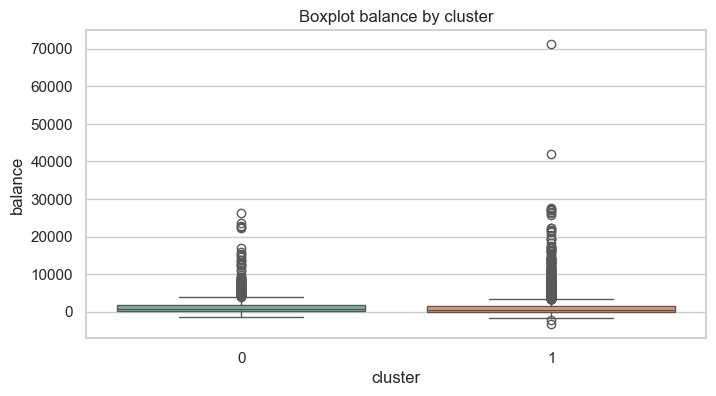

C:\Users\Duong\AppData\Local\Temp\ipykernel_3204\11713911.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y=col, data=df, palette='Set2')


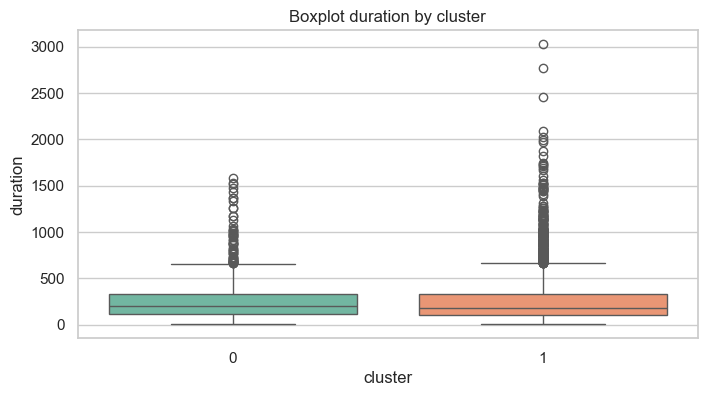

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')

df = pd.read_csv("../data/processed/bank_clean.csv")

# Chọn một số biến numeric đại diện (hoặc tất cả numeric)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Numeric cols:', numeric_cols)

X = df[numeric_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Tìm K tốt nhất
inertia = []
silhouette = []
K_candidates = range(2, 8)
for k in K_candidates:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_candidates, inertia, '-o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method for K')

plt.subplot(1, 2, 2)
plt.plot(K_candidates, silhouette, '-o', color='orange')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for K')
plt.tight_layout()
plt.show()

best_k = K_candidates[int(np.argmax(silhouette))]
print('Best K by silhouette:', best_k)

# Áp dụng KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)
df['cluster'] = cluster_labels

# Visualization age vs balance
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['age'], df['balance'], c=df['cluster'], cmap='tab10', alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Balance')
plt.title('Clusters by Age and Balance')
plt.legend(*scatter.legend_elements(), title='cluster')
plt.show()

# Characterize clusters
profile = df.groupby('cluster')[numeric_cols + ['y']].agg(['mean', 'median', 'count'])
print(profile)

# Biểu đồ profile chọn 3 cột
for col in ['age', 'balance', 'duration']:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x='cluster', y=col, data=df, palette='Set2')
        plt.title(f'Boxplot {col} by cluster')
        plt.show()